(array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]

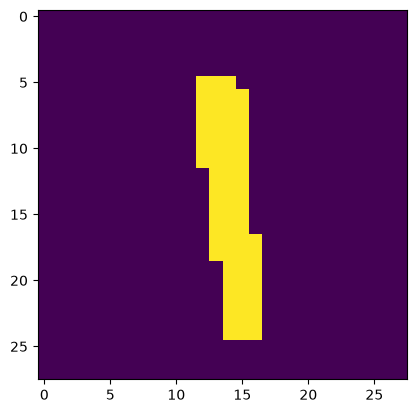

Сеть net:
Количетво слоев: 3
Количество нейронов в слое 0 : 784
Количество нейронов в слое 1 : 30
Количество нейронов в слое 2 : 10
W_ 1 :
[[-0.07  0.06 -0.12 ...  1.13  1.63 -0.66]
 [ 0.68 -0.54 -0.42 ...  0.99 -0.89 -0.5 ]
 [-1.75  1.36  1.27 ... -0.64  0.89 -0.81]
 ...
 [ 0.56  0.89 -0.89 ...  0.42  1.07  0.05]
 [-0.31 -0.5  -1.04 ... -1.05 -1.9  -0.15]
 [ 0.86  0.97  1.93 ... -0.78  0.7   0.39]]
b_ 1 :
[[-0.92]
 [-0.07]
 [ 0.18]
 [ 0.19]
 [ 0.59]
 [ 0.05]
 [ 0.72]
 [-0.52]
 [ 0.39]
 [ 0.73]
 [ 1.25]
 [ 0.64]
 [ 3.37]
 [-0.5 ]
 [ 0.68]
 [ 1.51]
 [-2.78]
 [ 0.24]
 [ 0.72]
 [-0.73]
 [-0.32]
 [ 0.09]
 [ 0.87]
 [-0.48]
 [-1.14]
 [ 1.25]
 [-0.31]
 [-0.28]
 [ 1.22]
 [ 0.21]]
W_ 2 :
[[ 0.31 -0.73  0.85 -0.42 -1.34 -0.8  -0.52  0.27  0.13 -1.46 -2.26 -0.71
  -1.8   0.92 -0.84 -0.81 -0.08 -1.21 -0.8  -0.06  0.6  -1.   -0.63  1.06
  -0.44  0.94 -0.08  1.53  0.39  0.43]
 [-0.32 -1.31  1.54  0.01  0.2  -1.55  0.72 -1.88 -1.57 -0.46 -1.11  0.41
  -0.82 -1.24  0.43 -0.66 -1.24 -0.04  0.59 -1.65  

In [1]:
import random
import os
import numpy as np

class Network(object):  # используется для описания нейронной сети
    def __init__(self, sizes):  # конструктор класса
        # self – указатель на объект класса
        # sizes – список размеров слоев нейронной сети
        self.num_layers = len(sizes)  # задаем количество слоев нейронной сети
        self.sizes = sizes  # задаем список размеров слоев нейронной сети
        self.biases = [np.random.randn(y, 1) for y in sizes[1:]]  # задаем случайные начальные смещения
        self.weights = [np.random.randn(y, x) for x, y in
                        zip(sizes[:-1], sizes[1:])]  # задаем случайные начальные веса связей

    def sigmoid(self, z):  # определение сигмоидальной функции активации
        return 1.0 / (1.0 + np.exp(-z))

    def feedforward(self, a):
        for b, w in zip(self.biases, self.weights):
            a = self.sigmoid(np.dot(w, a) + b)
        return a

    def SGD(  # Стохастический градиентный спуск
            self  # указатель на объект класса
            , training_data  # обучающая выборка
            , epochs  # количество эпох обучения
            , mini_batch_size  # размер подвыборки
            , eta  # скорость обучения
            , test_data  # тестирующая выборка
    ):
        test_data = list(test_data)  # создаем список объектов тестирующей выборки
        n_test = len(test_data)  # вычисляем длину тестирующей выборки
        training_data = list(training_data)  # создаем список объектов обучающей выборки
        n = len(training_data)  # вычисляем размер обучающей выборки
        for j in range(epochs):  # цикл по эпохам
            random.shuffle(training_data)  # перемешиваем элементы обучающей выборки
            mini_batches = [training_data[k:k + mini_batch_size] for k in
                            range(0, n, mini_batch_size)]  # создаем подвыборки
            for mini_batch in mini_batches:  # цикл по подвыборкам
                #print(len(mini_batch[0][0]))
                self.update_mini_batch(mini_batch, eta)  # один шаг градиентного спуска
            print("Epoch {0}: {1} / {2}".format(j, self.evaluate(test_data), n_test))  # смотрим прогресс в обучении

    def update_mini_batch(  # Шаг градиентного спуска
            self  # указатель на объект класса
            , mini_batch  # подвыборка
            , eta  # скорость обучения
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        for x, y in mini_batch:
            delta_nabla_b, delta_nabla_w = self.backprop(x,
                                                         y)  # послойно вычисляем градиенты dC/db и dC/dw для текущего прецедента (x, y)
            nabla_b = [nb + dnb for nb, dnb in zip(nabla_b,
                                                   delta_nabla_b)]  # суммируем градиенты dC/db для различных прецедентов текущей подвыборки
            nabla_w = [nw + dnw for nw, dnw in zip(nabla_w,
                                                   delta_nabla_w)]  # суммируем градиенты dC/dw для различных прецедентов текущей подвыборки
        self.weights = [w - (eta / len(mini_batch)) * nw for w, nw in
                        zip(self.weights, nabla_w)]  # обновляем все веса w нейронной сети
        self.biases = [b - (eta / len(mini_batch)) * nb for b, nb in
                       zip(self.biases, nabla_b)]  # обновляем все смещения b нейронной сети

    def backprop(  # Алгоритм обратного распространения
            self  # указатель на объект класса
            , x  # вектор входных сигналов ,
            , y  # ожидаемый вектор выходных сигналов
    ):
        nabla_b = [np.zeros(b.shape) for b in
                   self.biases]  # список градиентов dC/db для каждого слоя (первоначально заполняются нулями)
        nabla_w = [np.zeros(w.shape) for w in
                   self.weights]  # список градиентов dC/dw для каждого слоя (первоначально заполняются нулями)
        # определение переменных
        activation = x  # выходные сигналы слоя (первоначально соответствует выходным сигналам 1-го слоя или входным сигналам сети)
        activations = [
            x]  # список выходных сигналов по всем слоям (первоначально содержит только выходные сигналы 1-го слоя)
        zs = []  # список активационных потенциалов по всем слоям (первоначально пуст)
        # прямое распространение
        for b, w in zip(self.biases, self.weights):
            z = np.dot(w, activation) + b  # считаем активационные потенциалы текущего слоя
            zs.append(z)  # добавляем элемент (активационные потенциалы слоя) в конец списка
            activation = self.sigmoid(
                z)  # считаем выходные сигналы текущего слоя, применяя сигмоидальную функцию активации к активационным потенциалам слоя
            activations.append(activation)  # добавляем элемент (выходные сигналы слоя) в конец списка
        # обратное распространение
        delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(
            zs[-1])  # считаем меру влияния нейронов выходного слоя L на величину ошибки (BP1)
        nabla_b[-1] = delta  # градиент dC/db для слоя L (BP3)
        nabla_w[-1] = np.dot(delta, activations[-2].transpose())  # градиент dC/dw для слоя L (BP4)
        for l in range(2, self.num_layers):
            z = zs[-l]  # активационные потенциалы l-го слоя (двигаемся по списку справа налево)
            sp = self.sigmoid_prime(z)  # считаем сигмоидальную функцию от активационных потенциалов l-го слоя
            delta = np.dot(self.weights[-l + 1].transpose(),
                           delta) * sp  # считаем меру влияния нейронов l-го слоя на величину ошибки (BP2)
            nabla_b[-l] = delta  # градиент dC/db для l-го слоя (BP3)
            nabla_w[-l] = np.dot(delta, activations[-l - 1].transpose())  # градиент dC/dw для l-го слоя (BP4)
        return (nabla_b, nabla_w)

    def evaluate(self, test_data):  # Оценка прогресса в обучении
        test_results = [(np.argmax(self.feedforward(x)), y) for (x, y) in test_data]
        return sum(int(x == y) for (x, y) in test_results)

    def cost_derivative(self, output_activations,
                        y):  # Вычисление частных производных стоимостной функции по выходным сигналам последнего слоя
        return (output_activations - y)

    def sigmoid_prime(self, z):  # Производная сигмоидальной функции
        return self.sigmoid(z) * (1 - self.sigmoid(z))

def load_data(path, n):
    with np.load(path) as f:
        (x_train, y_train) = f['x_train'][:n], f['y_train'][:n]
        (x_test, y_test) = f['x_test'], f['y_test']
    return ((x_train, y_train), (x_test, y_test))


(x_train, y_train), (x_test, y_test) = load_data('mnist.npz', 60000)

X_train = []
thresholdedData = []
for i in range(len(x_train)):
    row = np.reshape(x_train[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_train.append(thresholdedData)

X_test = []
thresholdedData = []
for i in range(len(x_test)):
    row = np.reshape(x_test[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_test.append(thresholdedData)


def load_data_wrapper(n, load='mnist.npz'):
    #tr_d, te_d = load_data(path) # инициализация наборов данных в формате MNIST
    (x_train, y_train), (x_test, y_test) = load_data(load, n)
    training_inputs = [((np.reshape(x, (784, 1)) > 0) * 1.0) for x in
                       (x_train)]  # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    training_results = [vectorized_result(y) for y in
                        (y_train)]  # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    training_data = list(zip(training_inputs, training_results))  # формируем набор обучающих данных из пар (x, y)
    # validation_inputs = [np.reshape(x, (784, 1)) for x in va_d[0]] # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    # validation_data = zip(validation_inputs, va_d[1]) # формируем набор данных проверки из пар (x, y)
    test_inputs = [((np.reshape(x, (784, 1)) > 0) * 1.0) for x in
                   (x_test)]  # преобразование массивов размера 1 на 784 к массивам размера 784 на 1
    #test_results = [vectorized_result(y) for y in (y_test)] # представление цифр от 0 до 9 в виде массивов размера 10 на 1
    test_data = list(zip(test_inputs, y_test))  # формируем набор тестовых данных из пар (x, y)
    return (training_data, test_data)

def vectorized_result(j):
    e = np.zeros((10, 1))
    e[j] = 1.0
    return e


import matplotlib.pyplot as plt

training_data, test_data = load_data_wrapper(50000)
print(training_data[8])
lll8 = np.reshape(training_data[8][0], (28, 28))
plt.imshow(lll8)
plt.show()
net = Network([784, 30, 10])
""" Вывод результата на экран: """
print('Сеть net:')
print('Количетво слоев:', net.num_layers)
for i in range(net.num_layers):
    print('Количество нейронов в слое', i, ':', net.sizes[i])
for i in range(net.num_layers - 1):
    print('W_', i + 1, ':')
    print(np.round(net.weights[i], 2))
    print('b_', i + 1, ':')
    print(np.round(net.biases[i], 2))

MODEL_FILE = 'emnist_model.npz'

if os.path.exists(MODEL_FILE):
    data = np.load(MODEL_FILE, allow_pickle=True)

    net.weights = list(data['weights'])
    net.biases = list(data['biases'])

else:

    net.SGD(
        training_data,
        30,
        10,
        3.0,
        test_data=test_data
    )

    np.savez(
        MODEL_FILE,
        weights=np.array(net.weights, dtype=object),
        biases=np.array(net.biases, dtype=object)
    )

# Forward propagate input to a network output
def forward_propagate(net, row):
    inputs = row
    for i in range(net.num_layers - 1):
        new_inputs = []
        for b, w in zip(net.biases[i], net.weights[i]):
            activation = np.dot(w, inputs) + b
            out = net.sigmoid(activation)
            new_inputs.append(out)
        inputs = new_inputs
    return new_inputs


# Make a prediction with a network
def predict(net, row):
    outputs = forward_propagate(net, row)
    return outputs.index(max(outputs))


i = -1
X_train = []
thresholdedData = []

for i in range(len(x_train)):
    row = np.reshape(x_train[i], (1, 784))
    thresholdedData = (row > 0) * 1.0
    X_train.extend(thresholdedData)

for i in range(len(X_train)):
    prediction = predict(net, X_train[i])
    if (i == 0):
        predictTrain = np.array([[prediction]])
    else:
        predictTrain = np.append(predictTrain, [[prediction]], axis=0)

In [2]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_train, predictTrain))
print(classification_report(y_train, predictTrain))

[[5774    5   10   15    5   22   18    4   63    7]
 [   1 6593   29   26   12   13    8   13   38    9]
 [  29   11 5670   32   48   10   22   50   66   20]
 [  35   26   75 5687    6   99   14   58  105   26]
 [  10   15   22    2 5632    2   33   14   19   93]
 [  33   15   26   83   17 5101   51   10   67   18]
 [  26    5    8    3   24   47 5754    1   49    1]
 [  11   15   44   16   32    5    3 6066   16   57]
 [  26   41   30   51   21   41   34   18 5569   20]
 [  34   14    7   91   86   40    4   66   60 5547]]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      5923
           1       0.98      0.98      0.98      6742
           2       0.96      0.95      0.95      5958
           3       0.95      0.93      0.94      6131
           4       0.96      0.96      0.96      5842
           5       0.95      0.94      0.94      5421
           6       0.97      0.97      0.97      5918
           7       0.96      0.97   